In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import sys
import os

# Agrega la raíz del proyecto al path para importar scripts/
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Motor de base de datos reutilizando database.py del proyecto
from scripts.database import engine

# Estilo visual consistente
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas      {pd.__version__}")
print(f"   numpy       {np.__version__}")
print(f"   seaborn     {sns.__version__}")
print(f"   statsmodels {sm.__version__}")

2026-04-08 12:44:04.694 
  command:

    streamlit run /home/desarrollo/etl-weatherstack/venv/lib/python3.12/site-packages/ipykernel_launcher.py [ARGUMENTS]


✅ Librerías importadas correctamente
   pandas      2.2.0
   numpy       1.26.4
   seaborn     0.13.2
   statsmodels 0.14.4


In [2]:
# ── CELDA 2: Carga de datos desde PostgreSQL ─────────────────
QUERY = """
SELECT
    c.nombre        AS ciudad,
    r.temperatura,
    r.sensacion_termica,
    r.humedad,
    r.velocidad_viento,
    r.fecha_extraccion
FROM registros_clima r
JOIN ciudades c ON r.ciudad_id = c.id
ORDER BY r.fecha_extraccion
"""

df = pd.read_sql(QUERY, engine)

print(f"✅ Datos cargados exitosamente desde PostgreSQL")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")
print(f"\n📋 Primeras filas:")
df.head()

✅ Datos cargados exitosamente desde PostgreSQL
   Filas    : 3,000
   Columnas : 6

📋 Primeras filas:


,ciudad,temperatura,sensacion_termica,humedad,velocidad_viento,fecha_extraccion
0,Bogotá,12.5,12.2,80.0,17.3,2026-03-22 04:12:00
1,Medellín,18.5,16.6,70.0,5.8,2026-03-22 04:12:00
2,Cali,27.0,25.6,71.0,9.1,2026-03-22 04:12:00
3,Barranquilla,32.0,31.3,82.0,24.1,2026-03-22 04:12:00
4,Cartagena,29.1,27.0,86.0,17.0,2026-03-22 04:12:00


In [3]:
# ── CELDA 3: Inspección del DataFrame ────────────────────────
print("=" * 50)
print("  INFORMACIÓN GENERAL DEL DATASET")
print("=" * 50)
print(df.info())
print("\n📊 Valores nulos por columna:")
print(df.isnull().sum())
print(f"\n🏙️  Ciudades en el dataset:")
print(df['ciudad'].value_counts())


  INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ciudad             3000 non-null   object        
 1   temperatura        3000 non-null   float64       
 2   sensacion_termica  3000 non-null   float64       
 3   humedad            3000 non-null   float64       
 4   velocidad_viento   3000 non-null   float64       
 5   fecha_extraccion   3000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 140.8+ KB
None

📊 Valores nulos por columna:
ciudad               0
temperatura          0
sensacion_termica    0
humedad              0
velocidad_viento     0
fecha_extraccion     0
dtype: int64

🏙️  Ciudades en el dataset:
ciudad
Bogotá          600
Medellín        600
Cali            600
Barranquilla    600
Cartagena       600
Name: count, dtype: int64

In [4]:
# ── CELDA 4: Estadísticas descriptivas ───────────────────────
vars_num = ['temperatura', 'sensacion_termica', 'humedad', 'velocidad_viento']

desc = df[vars_num].describe().round(2)
print("📊 ESTADÍSTICAS DESCRIPTIVAS")
print(desc)

📊 ESTADÍSTICAS DESCRIPTIVAS
       temperatura  sensacion_termica  humedad  velocidad_viento
count      3000.00            3000.00  3000.00           3000.00
mean         25.63              24.13    75.99             15.43
std           7.57               7.60     8.57              5.21
min           6.70               5.20    52.00              0.80
25%          19.80              18.27    70.00             11.60
50%          26.90              25.30    76.00             15.05
75%          31.42              30.10    82.00             19.10
max          40.60              40.60    99.00             31.00


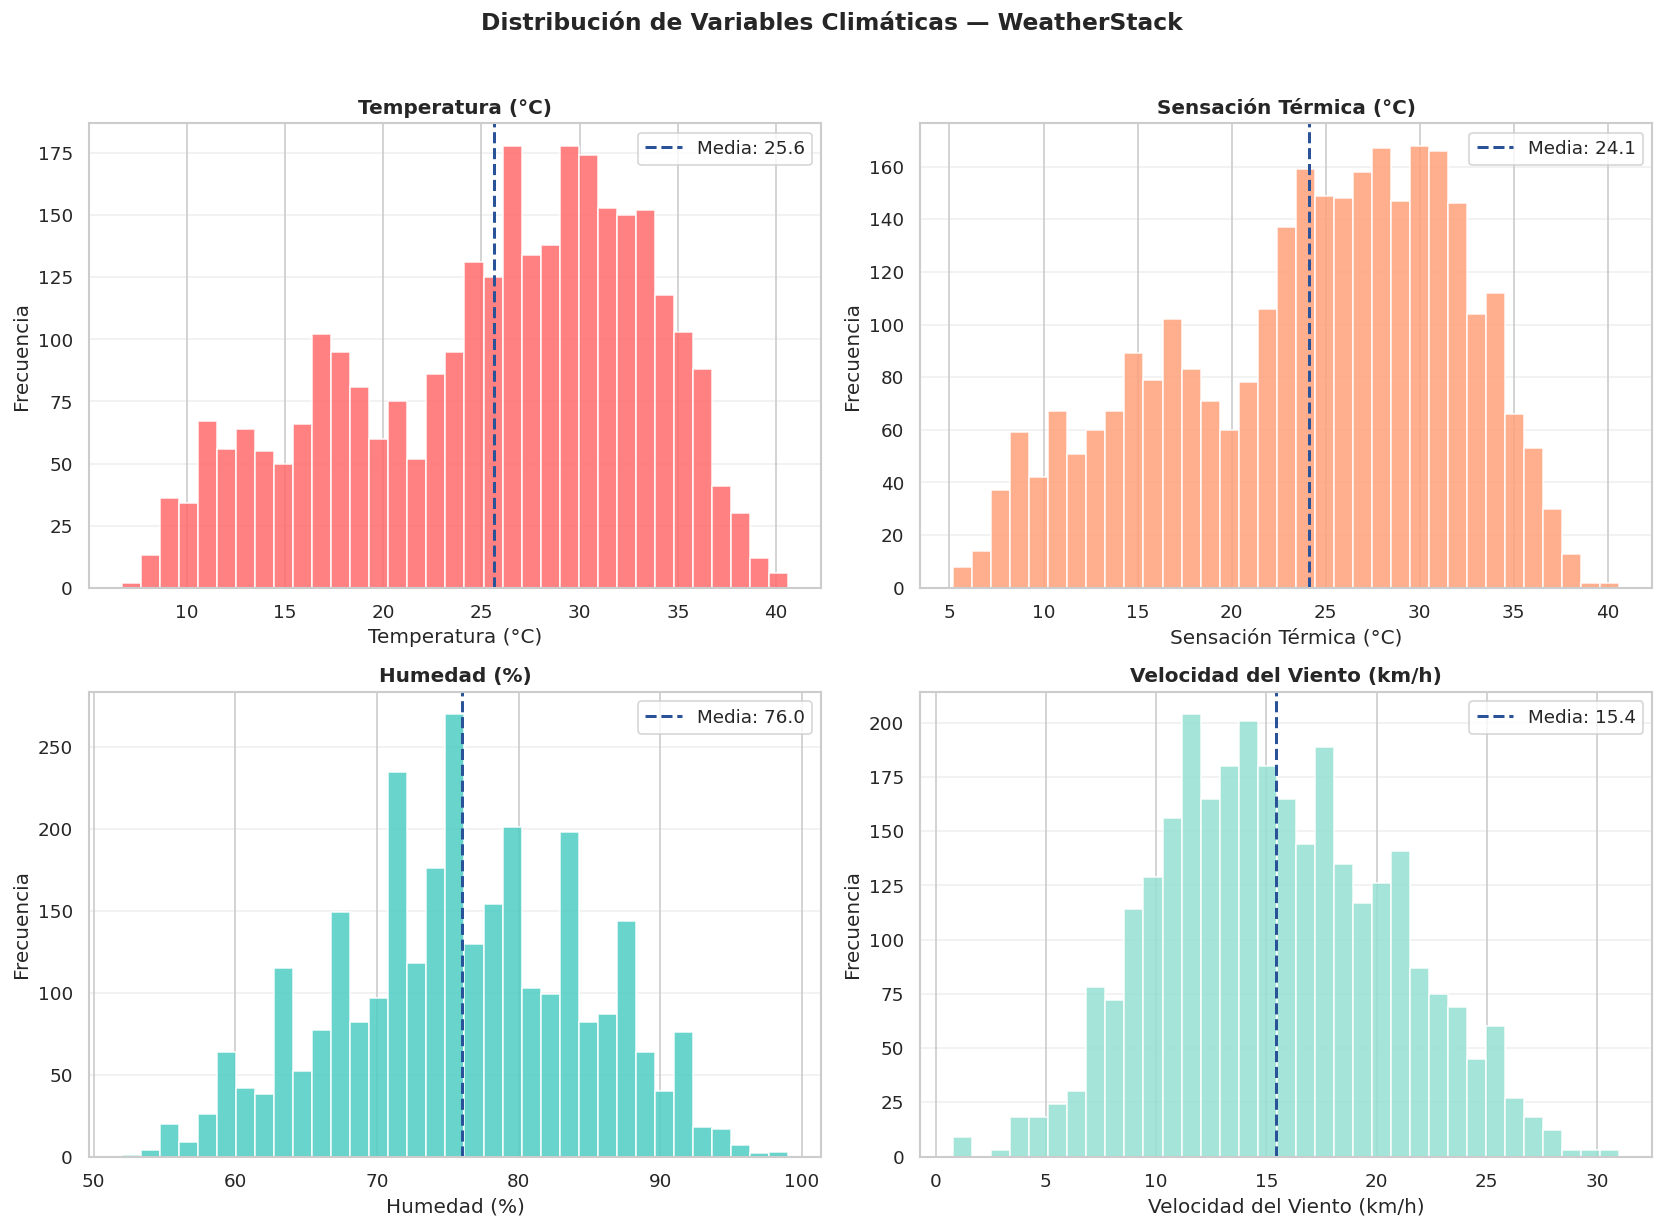

In [5]:
# ── CELDA 5: Histogramas de distribución ─────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Variables Climáticas — WeatherStack',
             fontsize=14, fontweight='bold', y=1.02)

datos = {
    'temperatura':       ('Temperatura (°C)',          '#ff6b6b'),
    'sensacion_termica': ('Sensación Térmica (°C)',     '#ffa07a'),
    'humedad':           ('Humedad (%)',                '#4ecdc4'),
    'velocidad_viento':  ('Velocidad del Viento (km/h)','#95e1d3'),
}

for ax, (col, (label, color)) in zip(axes.flat, datos.items()):
    ax.hist(df[col], bins=35, color=color, edgecolor='white', alpha=0.85)
    media = df[col].mean()
    ax.axvline(media, color='#2a5298', linestyle='--', linewidth=1.8,
               label=f'Media: {media:.1f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/eda_distribuciones.png',
            dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_9201/2177733011.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ciudad', y='temperatura', order=orden,
/tmp/ipykernel_9201/2177733011.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ciudad', y='humedad', order=orden,


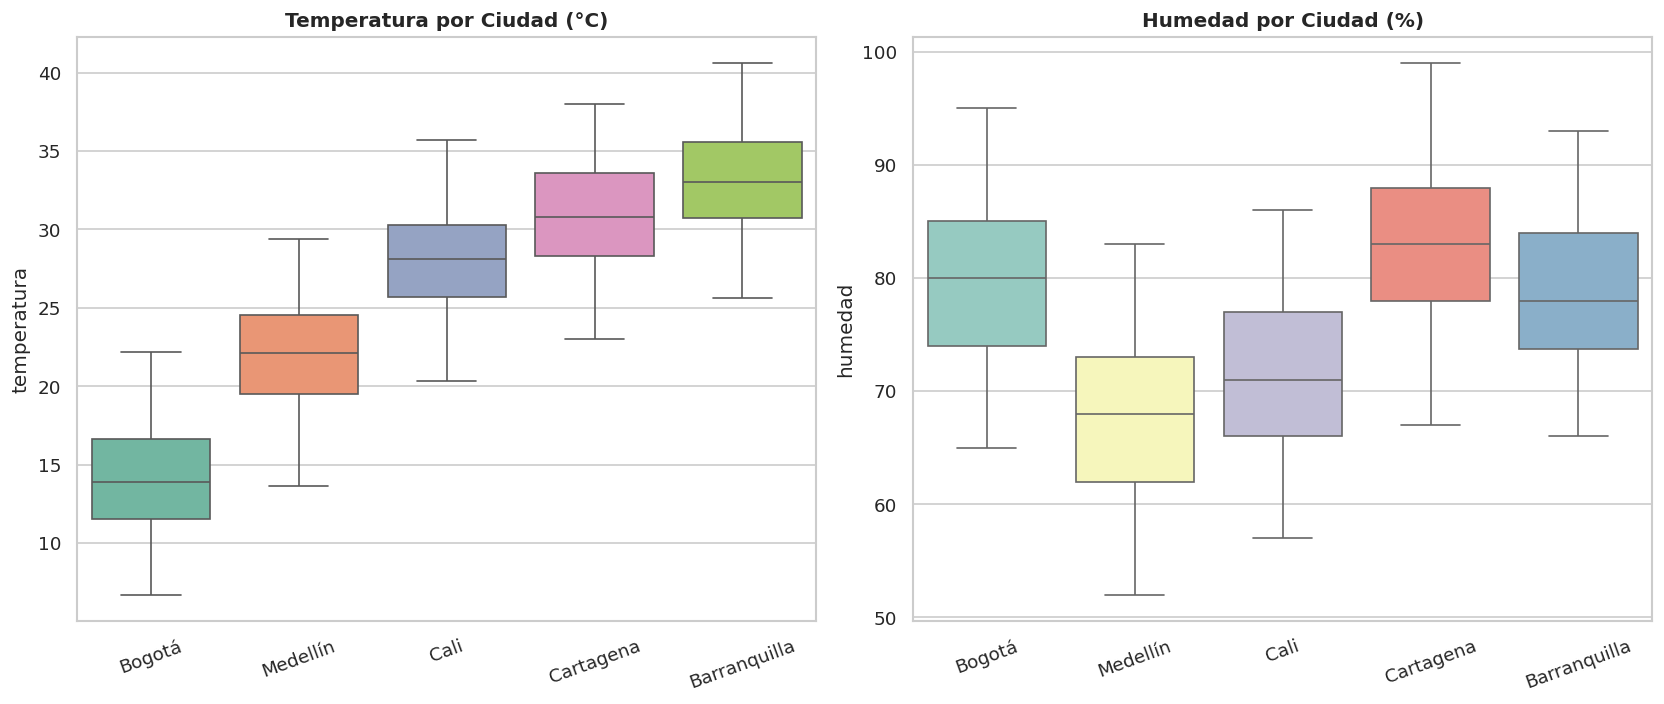

In [6]:
# ── CELDA 6: Boxplots por ciudad ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

orden = df.groupby('ciudad')['temperatura'].median().sort_values().index

sns.boxplot(data=df, x='ciudad', y='temperatura', order=orden,
            palette='Set2', ax=axes[0])
axes[0].set_title('Temperatura por Ciudad (°C)', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df, x='ciudad', y='humedad', order=orden,
            palette='Set3', ax=axes[1])
axes[1].set_title('Humedad por Ciudad (%)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('../data/graficas/eda_boxplots_ciudad.png',
            dpi=150, bbox_inches='tight')
plt.show()

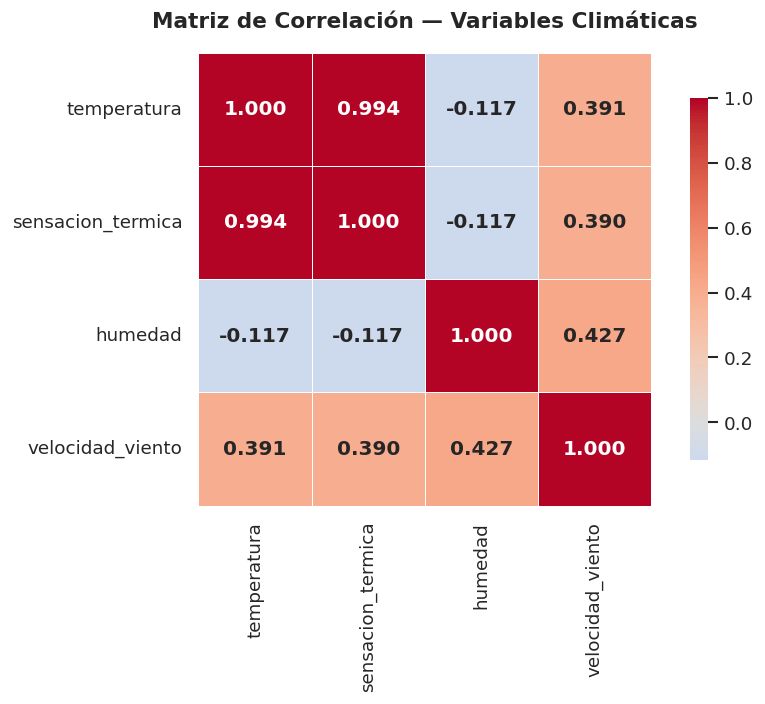


📊 Correlación con sensacion_termica (ordenada):
temperatura         0.9937
velocidad_viento    0.3898
humedad            -0.1169
Name: sensacion_termica, dtype: float64


In [7]:
# ── CELDA 7: Matriz de correlación ───────────────────────────
corr = df[vars_num].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # triángulo superior
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.6, square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title('Matriz de Correlación — Variables Climáticas',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/graficas/eda_correlacion.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Correlación con sensacion_termica (ordenada):")
print(corr['sensacion_termica'].drop('sensacion_termica')
      .sort_values(ascending=False).round(4))

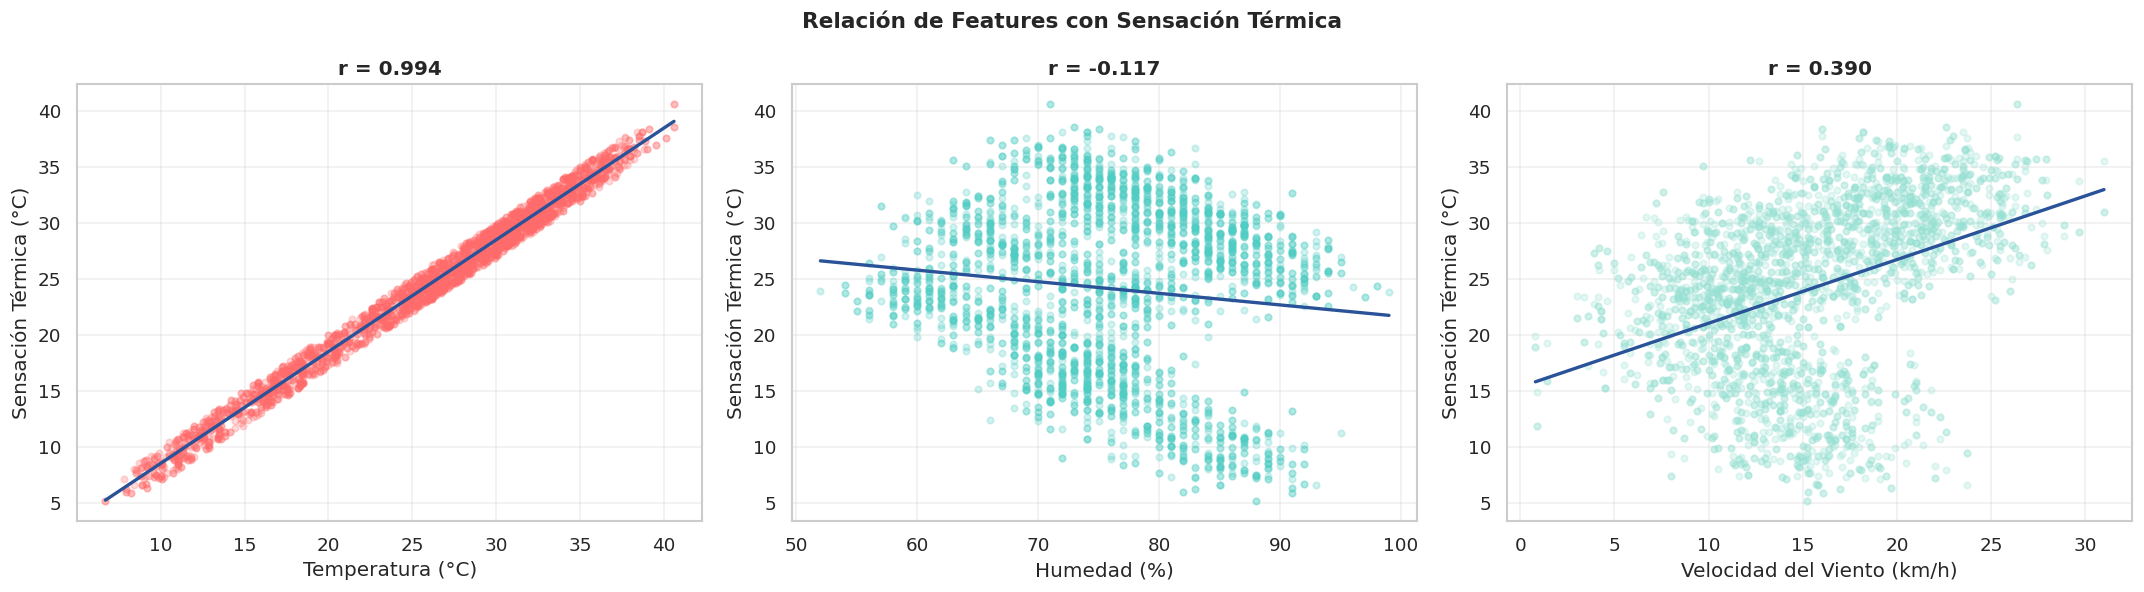

In [8]:
# ── CELDA 8: Scatter plots temperatura/humedad/viento vs sensacion ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Relación de Features con Sensación Térmica',
             fontsize=13, fontweight='bold')

pares = [
    ('temperatura',      'Temperatura (°C)',          '#ff6b6b'),
    ('humedad',          'Humedad (%)',                '#4ecdc4'),
    ('velocidad_viento', 'Velocidad del Viento (km/h)','#95e1d3'),
]

for ax, (feature, xlabel, color) in zip(axes, pares):
    ax.scatter(df[feature], df['sensacion_termica'],
               alpha=0.25, s=15, color=color)
    # Línea de tendencia
    z = np.polyfit(df[feature], df['sensacion_termica'], 1)
    p = np.poly1d(z)
    xp = np.linspace(df[feature].min(), df[feature].max(), 200)
    ax.plot(xp, p(xp), color='#2a5298', linewidth=2)
    r = df[[feature, 'sensacion_termica']].corr().iloc[0, 1]
    ax.set_title(f'r = {r:.3f}', fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Sensación Térmica (°C)')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/eda_scatter.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ── CELDA 9: Split Train / Test ───────────────────────────────
X_simple = df[['temperatura']].values
y        = df['sensacion_termica'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.20, random_state=42
)

print(f"Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(y)*100:.0f}%)")
print(f"Test : {X_test.shape[0]:,} muestras  ({X_test.shape[0]/len(y)*100:.0f}%)")

Train: 2,400 muestras (80%)
Test : 600 muestras  (20%)


In [10]:
# ── CELDA 10: Entrenamiento con scikit-learn ──────────────────
modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)

y_pred_simple = modelo_simple.predict(X_test)

print(f"Intercepto  β₀ : {modelo_simple.intercept_:.4f}")
print(f"Coeficiente β₁ : {modelo_simple.coef_[0]:.4f}")
print(f"\nEcuación : sensacion_termica = {modelo_simple.intercept_:.3f}"
      f" + {modelo_simple.coef_[0]:.3f} × temperatura")

Intercepto  β₀ : -1.4451
Coeficiente β₁ : 0.9979

Ecuación : sensacion_termica = -1.445 + 0.998 × temperatura


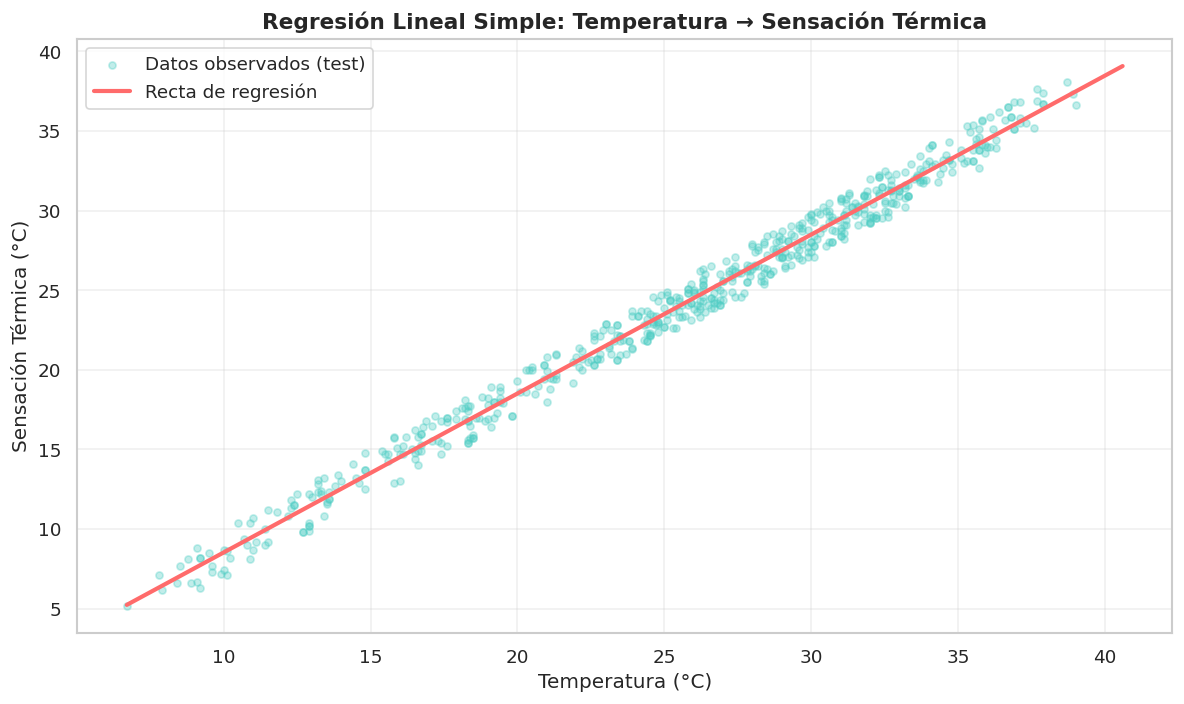

In [11]:
# ── CELDA 11: Recta de regresión ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X_test, y_test, alpha=0.35, s=18,
           color='#4ecdc4', label='Datos observados (test)')
x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
ax.plot(x_line, modelo_simple.predict(x_line),
        color='#ff6b6b', linewidth=2.5, label='Recta de regresión')

ax.set_xlabel('Temperatura (°C)', fontsize=12)
ax.set_ylabel('Sensación Térmica (°C)', fontsize=12)
ax.set_title('Regresión Lineal Simple: Temperatura → Sensación Térmica',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/regresion_simple.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ── CELDA 12: Métricas del modelo simple ─────────────────────
r2   = r2_score(y_test, y_pred_simple)
mse  = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_simple)

print("=" * 48)
print("    MÉTRICAS — REGRESIÓN LINEAL SIMPLE")
print("=" * 48)
print(f"  R²   (coef. determinación)  : {r2:.4f}  ({r2*100:.2f}%)")
print(f"  MSE  (error cuadrático med)  : {mse:.4f}")
print(f"  RMSE (raíz del MSE)          : {rmse:.4f}")
print(f"  MAE  (error absoluto medio)  : {mae:.4f}")
print("=" * 48)

    MÉTRICAS — REGRESIÓN LINEAL SIMPLE
  R²   (coef. determinación)  : 0.9875  (98.75%)
  MSE  (error cuadrático med)  : 0.6916
  RMSE (raíz del MSE)          : 0.8316
  MAE  (error absoluto medio)  : 0.7095


In [13]:
# ── CELDA 13: OLS statsmodels — resumen completo ─────────────
X_ols = sm.add_constant(df['temperatura'])   # agrega columna de constante
modelo_ols_simple = sm.OLS(df['sensacion_termica'], X_ols).fit()

print(modelo_ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:      sensacion_termica   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.987
Method:                 Least Squares   F-statistic:                 2.352e+05
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:44:16   Log-Likelihood:                -3777.0
No. Observations:                3000   AIC:                             7558.
Df Residuals:                    2998   BIC:                             7570.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -1.4395      0.055    -26.186      

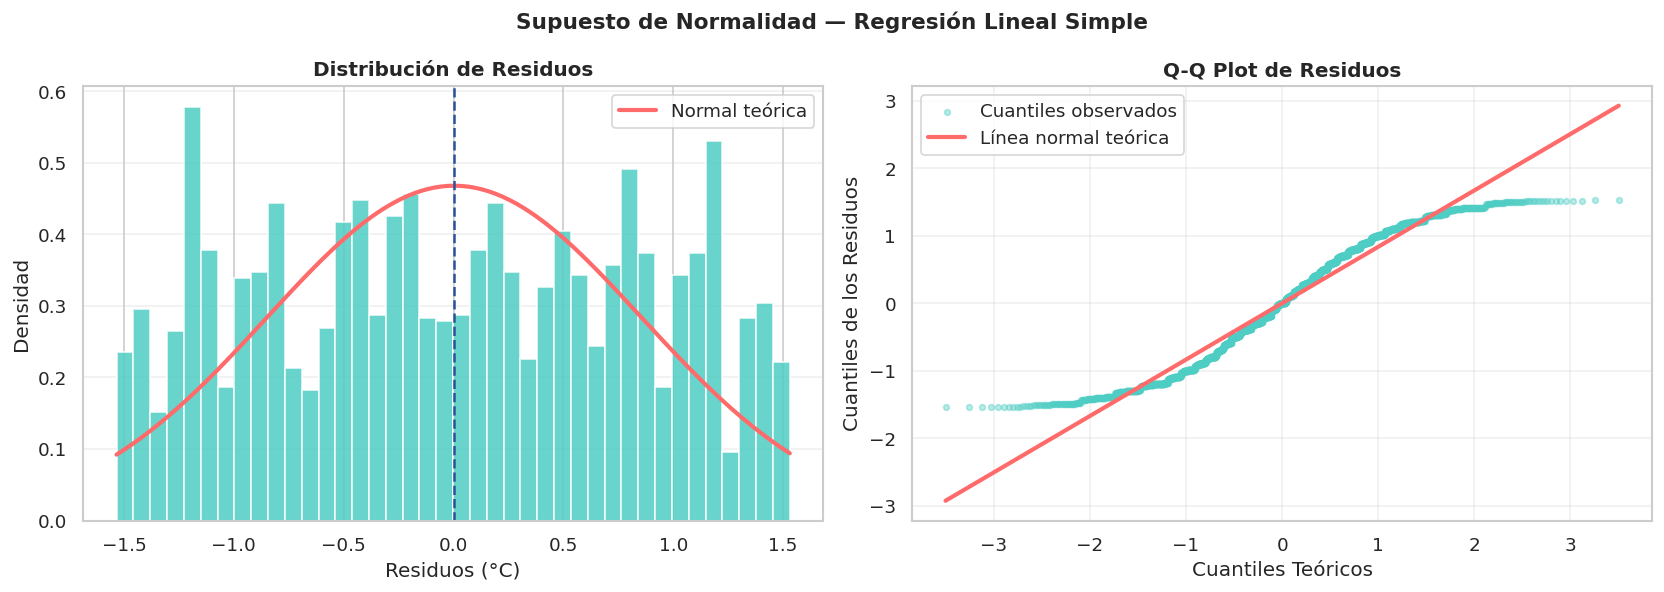


🔬 Test de Shapiro-Wilk:
   Estadístico W : 0.9591
   p-value       : 0.000000
   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)
   Nota: Con n ≥ 1000 el test es muy sensible — revisar Q-Q plot


In [14]:
# ── CELDA 14: Normalidad de residuos (modelo simple) ─────────
# Residuos sobre el dataset completo
y_pred_all = modelo_simple.predict(df[['temperatura']].values)
residuos   = df['sensacion_termica'].values - y_pred_all

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Supuesto de Normalidad — Regresión Lineal Simple',
             fontsize=13, fontweight='bold')

# Histograma con curva normal superpuesta
axes[0].hist(residuos, bins=40, color='#4ecdc4', edgecolor='white',
             density=True, alpha=0.85)
xr = np.linspace(residuos.min(), residuos.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos.mean(), residuos.std()),
             color='#ff6b6b', linewidth=2.5, label='Normal teórica')
axes[0].axvline(0, color='#2a5298', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos (°C)')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Q-Q Plot
(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')
axes[1].scatter(osm, osr, alpha=0.4, s=12, color='#4ecdc4',
                label='Cuantiles observados')
axes[1].plot(osm, slope * np.array(osm) + intercept,
             color='#ff6b6b', linewidth=2.5, label='Línea normal teórica')
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles de los Residuos')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/normalidad_simple.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Test Shapiro-Wilk (máximo 5000 muestras por limitación estadística)
muestra_sw = (residuos if len(residuos) <= 5000
              else np.random.default_rng(42).choice(residuos, 5000,
                                                    replace=False))
stat_sw, p_sw = stats.shapiro(muestra_sw)

print(f"\n🔬 Test de Shapiro-Wilk:")
print(f"   Estadístico W : {stat_sw:.4f}")
print(f"   p-value       : {p_sw:.6f}")
if p_sw > 0.05:
    print("   Conclusión    : ✅ No se rechaza normalidad (p > 0.05)")
else:
    print("   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)")
    print("   Nota: Con n ≥ 1000 el test es muy sensible — revisar Q-Q plot")

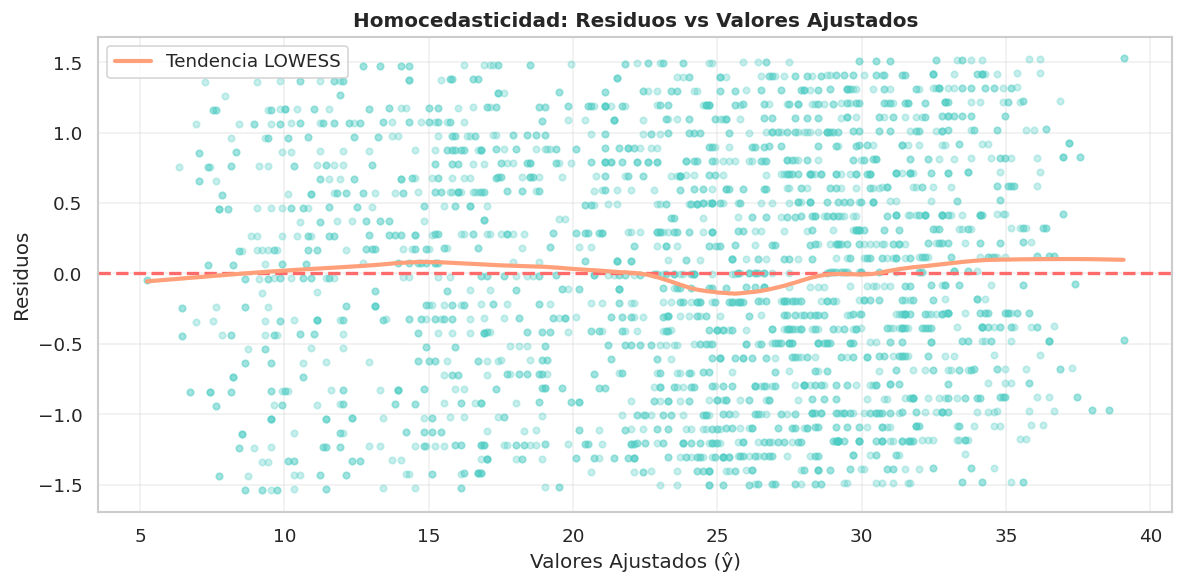


🔬 Test de Breusch-Pagan (Homocedasticidad):
   Estadístico LM : 0.0000
   p-value        : 0.997779
   Conclusión     : ✅ Homocedasticidad (p > 0.05)


In [15]:
# ── CELDA 15: Homocedasticidad (modelo simple) ───────────────
residuos_ols  = modelo_ols_simple.resid
ajustados_ols = modelo_ols_simple.fittedvalues

plt.figure(figsize=(10, 5))
plt.scatter(ajustados_ols, residuos_ols, alpha=0.30, s=15, color='#4ecdc4')
plt.axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
# Línea de tendencia suavizada LOWESS
lowess = sm.nonparametric.lowess(residuos_ols, ajustados_ols, frac=0.3)
plt.plot(lowess[:, 0], lowess[:, 1], color='#ffa07a', linewidth=2.5,
         label='Tendencia LOWESS')
plt.xlabel('Valores Ajustados (ŷ)', fontsize=12)
plt.ylabel('Residuos', fontsize=12)
plt.title('Homocedasticidad: Residuos vs Valores Ajustados',
          fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graficas/homoc_simple.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Test de Breusch-Pagan
lm, lm_p, fval, fp = het_breuschpagan(residuos_ols,
                                       modelo_ols_simple.model.exog)

print(f"\n🔬 Test de Breusch-Pagan (Homocedasticidad):")
print(f"   Estadístico LM : {lm:.4f}")
print(f"   p-value        : {lm_p:.6f}")
if lm_p > 0.05:
    print("   Conclusión     : ✅ Homocedasticidad (p > 0.05)")
else:
    print("   Conclusión     : ⚠️  Heterocedasticidad detectada (p ≤ 0.05)")

In [16]:
# ── CELDA 16: Preparación y entrenamiento — modelo múltiple ──
FEATURES = ['temperatura', 'humedad', 'velocidad_viento']

X_multi = df[FEATURES].values
y       = df['sensacion_termica'].values

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.20, random_state=42
)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

y_pred_multi = modelo_multi.predict(X_test_m)

print(f"Intercepto  β₀              : {modelo_multi.intercept_:.4f}")
for feat, coef in zip(FEATURES, modelo_multi.coef_):
    print(f"Coeficiente {feat:>18} : {coef:.4f}")

Intercepto  β₀              : -1.2814
Coeficiente        temperatura : 0.9964
Coeficiente            humedad : -0.0025
Coeficiente   velocidad_viento : 0.0043


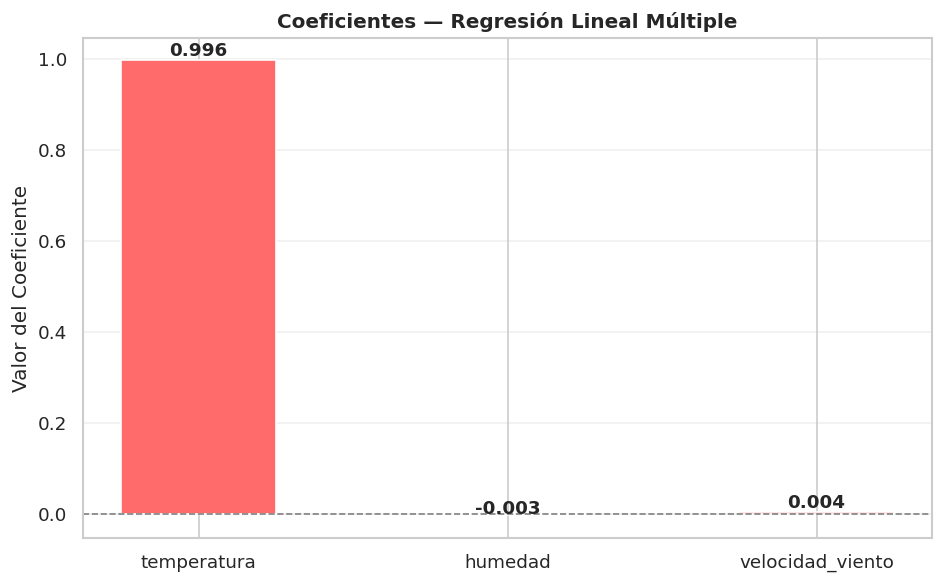

In [17]:
# ── CELDA 17: Gráfica de coeficientes ────────────────────────
colores = ['#ff6b6b' if c > 0 else '#4ecdc4' for c in modelo_multi.coef_]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(FEATURES, modelo_multi.coef_,
              color=colores, edgecolor='white', width=0.5)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Coeficientes — Regresión Lineal Múltiple',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Valor del Coeficiente')

for bar, coef in zip(bars, modelo_multi.coef_):
    offset = 0.002 if coef >= 0 else -0.005
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            f'{coef:.3f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graficas/coeficientes_multi.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ── CELDA 18: Métricas — modelo múltiple ─────────────────────
r2_m   = r2_score(y_test_m, y_pred_multi)
mse_m  = mean_squared_error(y_test_m, y_pred_multi)
rmse_m = np.sqrt(mse_m)
mae_m  = mean_absolute_error(y_test_m, y_pred_multi)

print("=" * 48)
print("  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE")
print("=" * 48)
print(f"  R²   (coef. determinación)  : {r2_m:.4f}  ({r2_m*100:.2f}%)")
print(f"  MSE  (error cuadrático med)  : {mse_m:.4f}")
print(f"  RMSE (raíz del MSE)          : {rmse_m:.4f}")
print(f"  MAE  (error absoluto medio)  : {mae_m:.4f}")
print("=" * 48)

  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE
  R²   (coef. determinación)  : 0.9875  (98.75%)
  MSE  (error cuadrático med)  : 0.6924
  RMSE (raíz del MSE)          : 0.8321
  MAE  (error absoluto medio)  : 0.7098


In [19]:
# ── CELDA 19: OLS statsmodels — modelo múltiple ──────────────
X_ols_m = sm.add_constant(df[FEATURES])
modelo_ols_multi = sm.OLS(df['sensacion_termica'], X_ols_m).fit()

print(modelo_ols_multi.summary())

                            OLS Regression Results                            
Dep. Variable:      sensacion_termica   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.987
Method:                 Least Squares   F-statistic:                 7.837e+04
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:44:18   Log-Likelihood:                -3776.6
No. Observations:                3000   AIC:                             7561.
Df Residuals:                    2996   BIC:                             7585.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -1.3186      0.165  

In [20]:
# ── CELDA 20: VIF — Factor de Inflación de la Varianza ───────
X_vif = df[FEATURES].copy()

vif_data = pd.DataFrame({
    "Variable": FEATURES,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})
vif_data["VIF"] = vif_data["VIF"].round(3)
vif_data["Criterio"] = vif_data["VIF"].apply(
    lambda v: "✅ Sin multicolinealidad (VIF < 5)"
              if v < 5
              else ("⚠️  Moderada (5 ≤ VIF < 10)"
                    if v < 10
                    else "❌ Severa (VIF ≥ 10)")
)

print("\n📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
print("=" * 60)
print(vif_data.to_string(index=False))
print("=" * 60)


📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
        Variable    VIF            Criterio
     temperatura 11.963 ❌ Severa (VIF ≥ 10)
         humedad 15.371 ❌ Severa (VIF ≥ 10)
velocidad_viento 13.978 ❌ Severa (VIF ≥ 10)


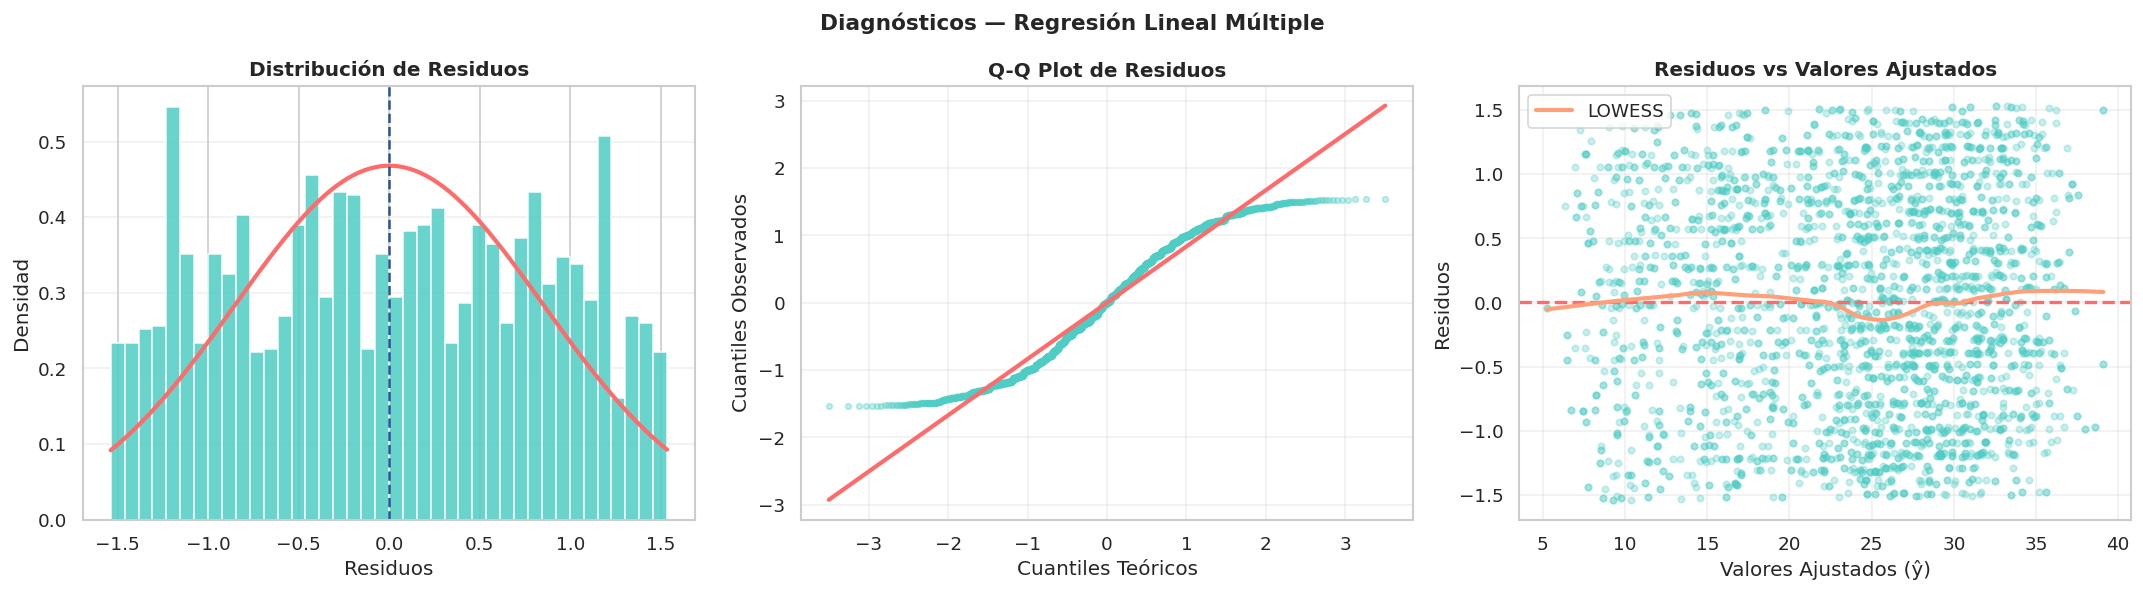


🔬 Test Shapiro-Wilk (Normalidad):
   p-value: 0.000000 → ⚠️  Se rechaza normalidad

🔬 Test Breusch-Pagan (Homocedasticidad):
   p-value: 0.305800 → ✅ Homocedasticidad OK


In [21]:
# ── CELDA 21: Diagnósticos completos — modelo múltiple ───────
residuos_m  = modelo_ols_multi.resid.values
ajustados_m = modelo_ols_multi.fittedvalues.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Diagnósticos — Regresión Lineal Múltiple',
             fontsize=13, fontweight='bold')

# ── Histograma de residuos
axes[0].hist(residuos_m, bins=40, color='#4ecdc4', edgecolor='white',
             density=True, alpha=0.85)
xr = np.linspace(residuos_m.min(), residuos_m.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos_m.mean(), residuos_m.std()),
             color='#ff6b6b', linewidth=2.5)
axes[0].axvline(0, color='#2a5298', linestyle='--')
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].grid(axis='y', alpha=0.3)

# ── Q-Q Plot
(osm, osr), (s, i, _) = stats.probplot(residuos_m, dist='norm')
axes[1].scatter(osm, osr, alpha=0.35, s=12, color='#4ecdc4')
axes[1].plot(osm, s * np.array(osm) + i,
             color='#ff6b6b', linewidth=2.5)
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles Observados')
axes[1].grid(alpha=0.3)

# ── Residuos vs Ajustados
axes[2].scatter(ajustados_m, residuos_m, alpha=0.30, s=15, color='#4ecdc4')
axes[2].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
lowess_m = sm.nonparametric.lowess(residuos_m, ajustados_m, frac=0.3)
axes[2].plot(lowess_m[:, 0], lowess_m[:, 1],
             color='#ffa07a', linewidth=2.5, label='LOWESS')
axes[2].set_title('Residuos vs Valores Ajustados', fontweight='bold')
axes[2].set_xlabel('Valores Ajustados (ŷ)')
axes[2].set_ylabel('Residuos')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/diagnosticos_multi.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Tests estadísticos
muestra_m = (residuos_m if len(residuos_m) <= 5000
             else np.random.default_rng(42).choice(residuos_m, 5000,
                                                   replace=False))
stat_sw_m, p_sw_m = stats.shapiro(muestra_m)
lm_m, lm_p_m, _, _ = het_breuschpagan(modelo_ols_multi.resid,
                                       modelo_ols_multi.model.exog)

print(f"\n🔬 Test Shapiro-Wilk (Normalidad):")
print(f"   p-value: {p_sw_m:.6f} → "
      f"{'✅ No se rechaza normalidad' if p_sw_m > 0.05 else '⚠️  Se rechaza normalidad'}")

print(f"\n🔬 Test Breusch-Pagan (Homocedasticidad):")
print(f"   p-value: {lm_p_m:.6f} → "
      f"{'✅ Homocedasticidad OK' if lm_p_m > 0.05 else '⚠️  Heterocedasticidad detectada'}")

In [22]:
# ── CELDA 22: Comparación final de modelos ───────────────────
comparacion = pd.DataFrame({
    'Modelo'   : ['Regresión Simple', 'Regresión Múltiple'],
    'Variables': ['temperatura',
                  'temperatura + humedad + velocidad_viento'],
    'R²'       : [round(r2, 4),    round(r2_m, 4)],
    'R² Aj.'   : [round(modelo_ols_simple.rsquared_adj, 4),
                  round(modelo_ols_multi.rsquared_adj, 4)],
    'RMSE'     : [round(rmse, 4),  round(rmse_m, 4)],
    'MAE'      : [round(mae, 4),   round(mae_m, 4)],
    'AIC'      : [round(modelo_ols_simple.aic, 2),
                  round(modelo_ols_multi.aic, 2)],
    'BIC'      : [round(modelo_ols_simple.bic, 2),
                  round(modelo_ols_multi.bic, 2)],
})

print("=" * 80)
print("              COMPARACIÓN DE MODELOS")
print("=" * 80)
print(comparacion.to_string(index=False))
print("=" * 80)
print("\n📌 AIC/BIC más bajo → mejor equilibrio entre ajuste y parsimonia")

              COMPARACIÓN DE MODELOS
            Modelo                                Variables     R²  R² Aj.   RMSE    MAE     AIC     BIC
  Regresión Simple                              temperatura 0.9875  0.9874 0.8316 0.7095 7558.08 7570.09
Regresión Múltiple temperatura + humedad + velocidad_viento 0.9875  0.9874 0.8321 0.7098 7561.16 7585.18

📌 AIC/BIC más bajo → mejor equilibrio entre ajuste y parsimonia


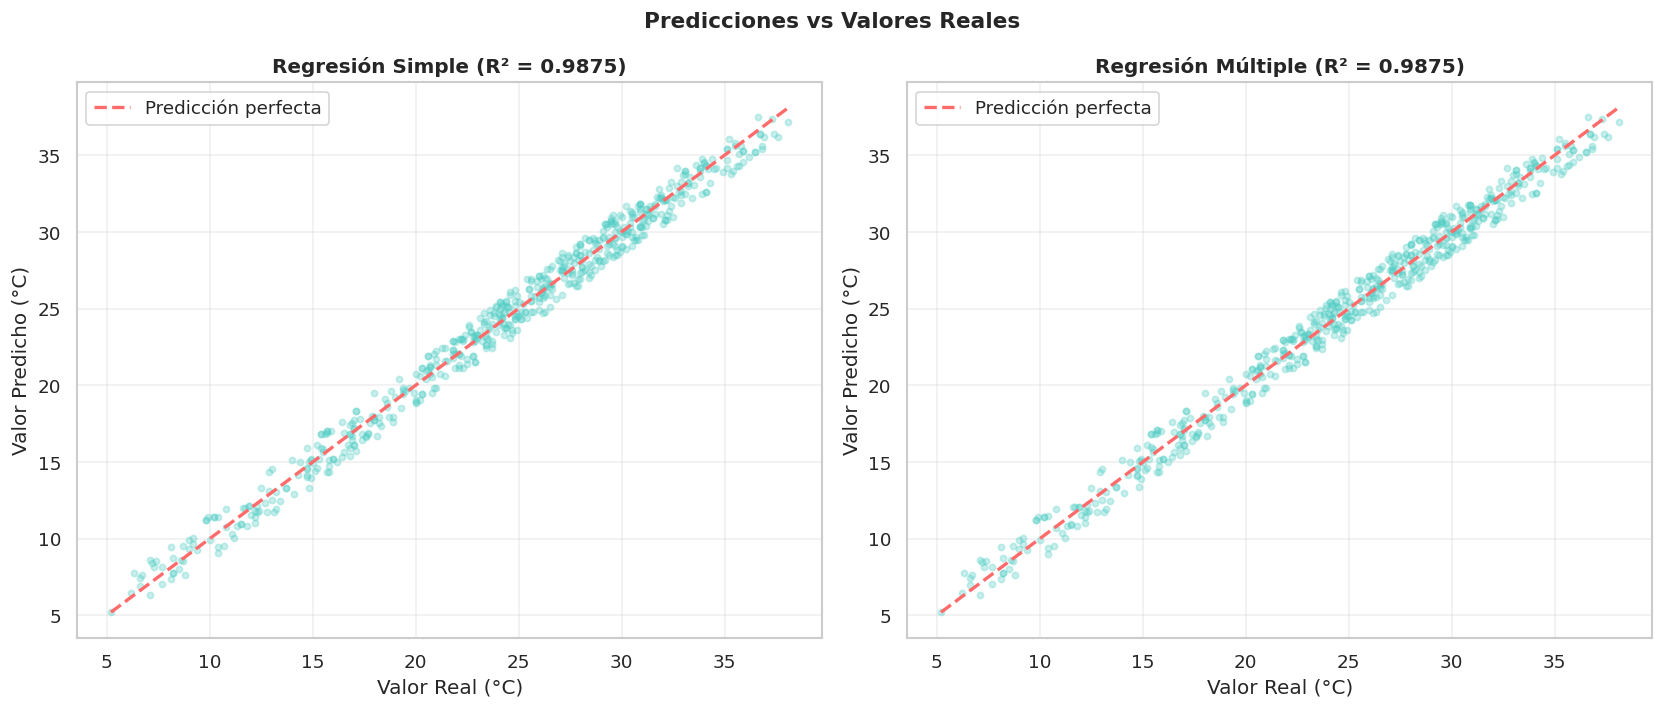

In [23]:
# ── CELDA 23: Predicciones vs Reales — ambos modelos ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Predicciones vs Valores Reales', fontsize=13, fontweight='bold')

for ax, (y_real, y_pred, titulo) in zip(axes, [
    (y_test,   y_pred_simple, 'Regresión Simple'),
    (y_test_m, y_pred_multi,  'Regresión Múltiple'),
]):
    minval = min(y_real.min(), y_pred.min())
    maxval = max(y_real.max(), y_pred.max())
    ax.scatter(y_real, y_pred, alpha=0.30, s=14, color='#4ecdc4')
    ax.plot([minval, maxval], [minval, maxval],
            color='#ff6b6b', linewidth=2, linestyle='--',
            label='Predicción perfecta')
    r2_val = r2_score(y_real, y_pred)
    ax.set_title(f'{titulo} (R² = {r2_val:.4f})', fontweight='bold')
    ax.set_xlabel('Valor Real (°C)')
    ax.set_ylabel('Valor Predicho (°C)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/predicciones_vs_reales.png',
            dpi=150, bbox_inches='tight')
plt.show()